In [1]:
import torch
import deepxde as dde

%cd ..
from models import FNO2d, FNO3d
from train_utils.datasets import MatReader, Burgers2DLoader

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


/home/jw3275/PI-FNO-reproduce


<h2>Generate Ground Truths</h2>

Generating 1000 samples of 2D inviscid Burgers ...
Processing sample 100/1000...
Processing sample 200/1000...
Processing sample 300/1000...
Processing sample 400/1000...
Processing sample 500/1000...
Processing sample 600/1000...
Processing sample 700/1000...
Processing sample 800/1000...
Processing sample 900/1000...
Processing sample 1000/1000...

Generation complete.
x shape: (1000, 64, 64)
y shape: (1000, 51, 64, 64)


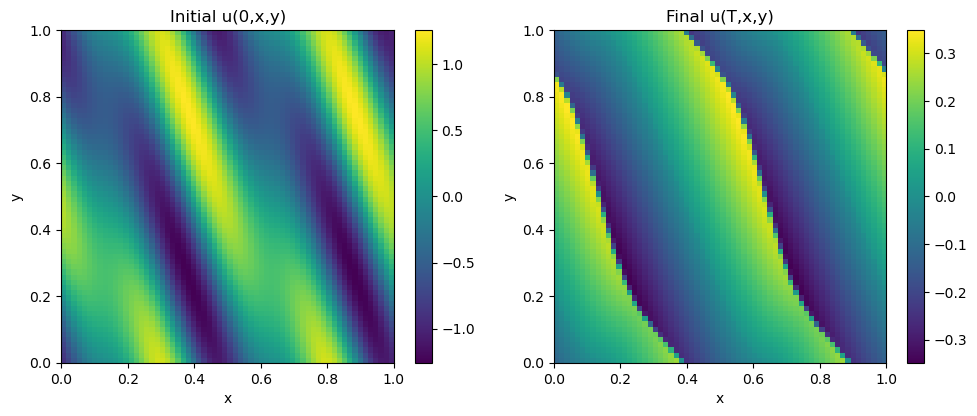

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2D Inviscid Burgers (periodic): u_t + (u^2/2)_x + (u^2/2)_y = 0
# Full time series output: (Nt, Nx, Ny)
# ------------------------------------------------------------

def sample_ic_sinusoidal_2d(Nx, Ny, kmax=4, amp=1.0, rng=None):
    """
    v(x,y) = a sin(2π(mx+ny)) + b cos(2π(px+qy)), periodic on [0,1)^2
    Returns v shape (Nx, Ny)
    """
    if rng is None:
        rng = np.random.default_rng()

    x = np.linspace(0, 1, Nx, endpoint=False)
    y = np.linspace(0, 1, Ny, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing="ij")  # (Nx, Ny)

    a = rng.uniform(-amp, amp)
    b = rng.uniform(-amp, amp)
    m = rng.integers(1, kmax + 1)
    n = rng.integers(1, kmax + 1)
    p = rng.integers(1, kmax + 1)
    q = rng.integers(1, kmax + 1)

    v = a * np.sin(2*np.pi*(m*X + n*Y)) + b * np.cos(2*np.pi*(p*X + q*Y))
    return v.astype(np.float32)


def burgers2d_step_rusanov(u, dt, dx, dy):
    """
    One Rusanov (local LF) step for:
      u_t + (u^2/2)_x + (u^2/2)_y = 0
    Periodic BCs via np.roll.
    u shape (Nx, Ny)
    """
    # x-direction numerical flux at i+1/2
    uR = np.roll(u, -1, axis=0)
    uL = u
    a = np.maximum(np.abs(uL), np.abs(uR))  # wave speed |df/du| = |u|
    Fx = 0.5*(0.5*uL**2 + 0.5*uR**2) - 0.5*a*(uR - uL)
    Fx_minus = np.roll(Fx, 1, axis=0)

    # y-direction numerical flux at j+1/2
    uU = np.roll(u, -1, axis=1)
    uD = u
    aY = np.maximum(np.abs(uD), np.abs(uU))
    Gy = 0.5*(0.5*uD**2 + 0.5*uU**2) - 0.5*aY*(uU - uD)
    Gy_minus = np.roll(Gy, 1, axis=1)

    # Conservative update
    u_new = u - (dt/dx)*(Fx - Fx_minus) - (dt/dy)*(Gy - Gy_minus)
    return u_new.astype(np.float32)


def solve_burgers2d_timeseries(u0, t_max=0.5, Nt=101, cfl=0.4, plot=False):
    u = u0.astype(np.float32).copy()
    Nx, Ny = u.shape
    dx = 1.0 / Nx
    dy = 1.0 / Ny

    # times = np.linspace(0.0, t_max, Nt, dtype=np.float32)
    times = np.linspace(0.0, t_max, Nt)  # float64

    u_series = np.empty((Nt, Nx, Ny), dtype=np.float32)
    u_series[0] = u

    t = 0.0
    k = 1

    steps = 0
    max_steps = 5_000_000


    while k < Nt:
        steps += 1
        if steps > max_steps:
            raise RuntimeError("Too many steps (possible CFL too small or NaN issue).")
    
        if not np.isfinite(u).all():
            raise RuntimeError("u became NaN/Inf, solver unstable.")
    
        umax = float(np.max(np.abs(u)))
        dt_cfl = cfl * min(dx, dy) / max(umax, 1e-6)
    
        dt_target = float(times[k] - t)
    
        # --- SNAP FIX ---
        if dt_target <= 1e-12:
            t = float(times[k])
            u_series[k] = u
            k += 1
            continue
    
        dt = min(dt_cfl, dt_target)
    
        if not np.isfinite(dt) or dt <= 0:
            raise RuntimeError(f"Bad dt={dt}, umax={umax}, t={t}, target={times[k]}")
    
        u = burgers2d_step_rusanov(u, dt, dx, dy)
        t += dt
    
        if t >= float(times[k]) - 1e-12:
            u_series[k] = u
            k += 1
    
    # safety
    u_series[-1] = u

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        im0 = ax[0].imshow(u_series[0], origin="lower", aspect="auto")
        ax[0].set_title("Initial u(0,x,y)")
        plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

        im1 = ax[1].imshow(u_series[-1], origin="lower", aspect="auto")
        ax[1].set_title(f"Final u({t_max},x,y)")
        plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return u_series



def create_burgers2d_dataset(N_SAMPLES=200, Nx=64, Ny=64, Nt=101,
                            X_MUL=1, T_MUL=1, t_max=0.5,
                            kmax=4, amp=1.0, seed=0, cfl=0.4):
    """
    Creates:
      x_data: (N, Nx, Ny)          initial conditions v(x,y)
      y_data: (N, Nt, Nx, Ny)      time series u(t,x,y)

    Uses X_MUL and T_MUL similarly to your advection code:
      - solve at (Nx*X_MUL, Ny*X_MUL) and ( (Nt-1)*T_MUL + 1 ) time steps
      - then downsample back to (Nx, Ny, Nt)
    """
    print(f"Generating {N_SAMPLES} samples of 2D inviscid Burgers ...")
    rng = np.random.default_rng(seed)

    Nx_hi = Nx * X_MUL
    Ny_hi = Ny * X_MUL
    Nt_hi = (Nt - 1) * T_MUL + 1

    x_data = np.zeros((N_SAMPLES, Nx, Ny), dtype=np.float32)
    y_data = np.zeros((N_SAMPLES, Nt, Nx, Ny), dtype=np.float32)

    for i in range(N_SAMPLES):
        every = max(1, N_SAMPLES // 10)   # prints ~10 times
        if (i + 1) % every == 0:
            print(f"Processing sample {i+1}/{N_SAMPLES}...", flush=True)

        # 1) IC at high-res
        u0_hi = sample_ic_sinusoidal_2d(Nx_hi, Ny_hi, kmax=kmax, amp=amp, rng=rng)

        # 2) Solve at high-res, full time series
        u_hi = solve_burgers2d_timeseries(u0_hi, t_max=t_max, Nt=Nt_hi, cfl=cfl, plot=False)  # (Nt_hi, Nx_hi, Ny_hi)

        # 3) Downsample
        x_data[i] = u0_hi[::X_MUL, ::X_MUL]                    # (Nx, Ny)
        y_data[i] = u_hi[::T_MUL, ::X_MUL, ::X_MUL]            # (Nt, Nx, Ny)

    data = {"x": x_data, "y": y_data}
    print("\nGeneration complete.")
    print("x shape:", data["x"].shape)  # (N, Nx, Ny)
    print("y shape:", data["y"].shape)  # (N, Nt, Nx, Ny)
    return data


# --- Example Usage / quick sanity plot ---
if __name__ == "__main__":
    data_dict = create_burgers2d_dataset(
        N_SAMPLES=1000, Nx=64, Ny=64, Nt=51, X_MUL=2, T_MUL=2, t_max=0.5,
        kmax=4, amp=1.0, seed=123, cfl=0.4
    )

    sample_idx = 0
    u_series = data_dict["y"][sample_idx]  # (Nt, Nx, Ny)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(u_series[0].T, origin="lower", extent=[0,1,0,1], aspect="equal")
    plt.title("Initial u(0,x,y)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar()
    
    plt.subplot(1,2,2)
    plt.imshow(u_series[-1].T, origin="lower", extent=[0,1,0,1], aspect="equal")
    plt.title("Final u(T,x,y)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()



In [ ]:
# Generate data
"""data_dict = create_burgers2d_dataset(N_SAMPLES=800, Nx=64, Ny=64, Nt=101, X_MUL=1, T_MUL=1, t_max=0.5)

import scipy.io

mat_data = {
    "input": data_dict["x"],   # (N, Nx, Ny)
    "output": data_dict["y"],  # (N, Nt, Nx, Ny)
}

scipy.io.savemat("/home/jw3275/PI-FNO-reproduce/data/burgers2d_pino.mat", mat_data, do_compression=True)
print("Saved to /home/jw3275/PI-FNO-reproduce/data/burgers2d_pino.mat")"""


In [3]:
import scipy.io
mat = scipy.io.loadmat("/home/jw3275/PI-FNO-reproduce/data/burgers2d_pino.mat")
print(mat.keys())
for k in ["input", "output"]:
    if k in mat:
        print(k, mat[k].shape, mat[k].dtype)


dict_keys(['__header__', '__version__', '__globals__', 'input', 'output'])
input (800, 64, 64) float32
output (800, 101, 64, 64) float32


<h2>Load model</h2>

In [3]:
# =========================
# Burgers2D PINO Evaluation (advection-style: new ICs each run)
# =========================
import os, yaml, numpy as np, torch
import matplotlib.pyplot as plt
#from models import FNO3d  # make sure this import works in your repo

import torch
import deepxde as dde

%cd ..
from models import FNO2d, FNO3d
from train_utils.datasets import MatReader, AdvectionLoader, Burgers2DLoader

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# ----------- USER: set these 2 paths -----------
CONFIG_PATH = "/home/jw3275/PI-FNO-reproduce/configs/pretrain/burgers2d_inviscid_pretrain_pino3d.yaml"   # change
CKPT_PATH   = "/home/jw3275/PI-FNO-reproduce/checkpoints/burgers2d-PINO/burgers2d_inviscid_fullseries_pino_data_1_pde_001_ic_0_ite_500.pt"      # change

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)



/home/jw3275
device: cpu


In [4]:
# ---------- load config ----------
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

dcfg = config["data"]
mcfg = config["model"]

Nx = int(dcfg["nx"])
Ny = int(dcfg.get("ny", dcfg["nx"]))
Nt = int(dcfg["nt"])
t_max = float(dcfg["time_interval"])

assert Nx == Ny, "This evaluation cell assumes square grid (nx==ny)."

# ---------- build model ----------
model = FNO3d(
    modes1=mcfg["modes1"],
    modes2=mcfg["modes2"],
    modes3=mcfg["modes3"],
    fc_dim=mcfg["fc_dim"],
    layers=mcfg["layers"],
).to(device)

# ---------- load checkpoint (save_checkpoint format) ----------
ckpt = torch.load(CKPT_PATH, map_location=device)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

# handle DDP "module." prefix if present
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
model.eval()
print("Loaded checkpoint:", CKPT_PATH)
print("Trainable params:", sum(p.numel() for p in model.parameters()))

Loaded checkpoint: /home/jw3275/PI-FNO-reproduce/checkpoints/burgers2d-PINO/burgers2d_inviscid_fullseries_pino_data_1_pde_001_ic_0_ite_500.pt
Trainable params: 138437441


In [5]:
# ---------- helpers ----------
def build_fno3d_input_from_u0(u0_batch, T, t_interval, device):
    """
    u0_batch: torch (B,S,S)
    return:   torch (B,S,S,T,4) = [x,y,t,u0]
    """
    B, S, _ = u0_batch.shape
    x = torch.linspace(0, 1, S+1, device=device)[:-1]
    y = torch.linspace(0, 1, S+1, device=device)[:-1]
    t = torch.linspace(0, t_interval, T, device=device)

    gridx = x.view(1, S, 1, 1, 1).repeat(B, 1, S, T, 1)
    gridy = y.view(1, 1, S, 1, 1).repeat(B, S, 1, T, 1)
    gridt = t.view(1, 1, 1, T, 1).repeat(B, S, S, 1, 1)
    u0rep = u0_batch.view(B, S, S, 1, 1).repeat(1, 1, 1, T, 1)

    a = torch.cat([gridx, gridy, gridt, u0rep], dim=-1)  # (B,S,S,T,4)
    return a


def rel_l2(a, b, eps=1e-12):
    return np.linalg.norm(a-b) / (np.linalg.norm(b) + eps)

def rel_l1(a, b, eps=1e-12):
    return np.sum(np.abs(a-b)) / (np.sum(np.abs(b)) + eps)

In [6]:
import matplotlib.gridspec as gridspec

def plot_snapshots(truth, pred, t_grid, t_list, title_prefix="2D Burgers — snapshots"):
    """
    truth/pred: (S,S,T)
    t_grid: (T,)
    3 rows: Truth / Pred / |Pred-Truth|
    Dedicated right column for colorbars (no overlap).
    We plot .T to match your convention (x horizontal, y vertical).
    """
    S, _, T = truth.shape

    def t_to_idx(t):
        return int(np.argmin(np.abs(t_grid - t)))

    idxs = [t_to_idx(t) for t in t_list]
    ncol = len(idxs)

    # Shared color scale for Truth+Pred
    vmin = float(min(truth[:, :, idxs].min(), pred[:, :, idxs].min()))
    vmax = float(max(truth[:, :, idxs].max(), pred[:, :, idxs].max()))

    # Shared color scale for |diff|
    err_stack = np.abs(pred[:, :, idxs] - truth[:, :, idxs])
    emin, emax = float(err_stack.min()), float(err_stack.max())

    # Layout: last column reserved for colorbars
    fig = plt.figure(figsize=(3.05*ncol + 1.2, 8.2))
    gs = gridspec.GridSpec(
        3, ncol + 1,
        width_ratios=[1]*ncol + [0.05],
        wspace=0.03, hspace=0.12
    )

    axes = np.empty((3, ncol), dtype=object)
    for i in range(3):
        for j in range(ncol):
            axes[i, j] = fig.add_subplot(gs[i, j])

    cax_main = fig.add_subplot(gs[0:2, -1])  # spans rows 0-1
    cax_err  = fig.add_subplot(gs[2, -1])    # row 2 only

    im_main = None
    im_err  = None

    for j, k in enumerate(idxs):
        im0 = axes[0, j].imshow(
            truth[:, :, k].T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=vmin, vmax=vmax
        )
        axes[0, j].set_title(f"Truth t={t_grid[k]:.3f}", fontsize=11)
        axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

        im1 = axes[1, j].imshow(
            pred[:, :, k].T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=vmin, vmax=vmax
        )
        axes[1, j].set_title(f"Pred t={t_grid[k]:.3f}", fontsize=11)
        axes[1, j].set_xticks([]); axes[1, j].set_yticks([])

        err = np.abs(pred[:, :, k] - truth[:, :, k])
        im2 = axes[2, j].imshow(
            err.T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=emin, vmax=emax
        )
        axes[2, j].set_title(f"|Diff| t={t_grid[k]:.3f}", fontsize=11)
        axes[2, j].set_xticks([]); axes[2, j].set_yticks([])

        if im_main is None: im_main = im0
        if im_err  is None: im_err  = im2

    cb1 = fig.colorbar(im_main, cax=cax_main)
    cb1.set_label("u", rotation=90)

    cb2 = fig.colorbar(im_err, cax=cax_err)
    cb2.set_label("|pred - truth|", rotation=90)

    fig.suptitle(title_prefix, y=0.99, fontsize=13)
    fig.subplots_adjust(top=0.93)
    plt.show()


Plotting snapshots for sample 0 ...


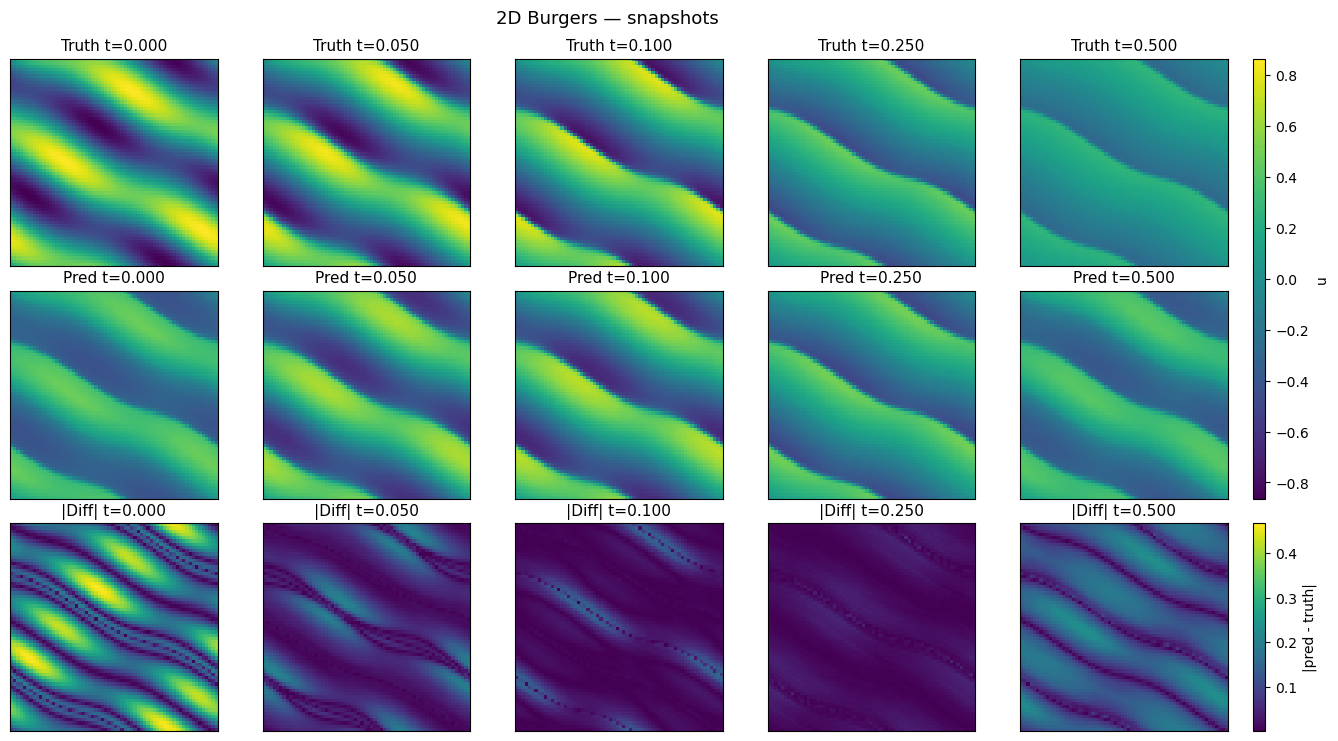


=== Summary over N_TEST = 100 ===
Mean rel L2 (space-time): 0.28121620416641235   Std: 0.08773403614759445
Mean rel L1 (space-time): 0.18234457075595856   Std: 0.04879424348473549


In [7]:
# ---------- evaluation settings ----------
N_TEST = 100          # increase for more stable metrics (but truth gen is slow)
EVAL_SEED = 100      # set None for different ICs each run (metrics will vary)
kmax = 4
amp = 1.0
cfl = 0.4

rng = np.random.default_rng(EVAL_SEED) if EVAL_SEED is not None else np.random.default_rng()

t_grid = np.linspace(0.0, t_max, Nt)  # float64 (consistent with your solver)
t_list = [0.0, 0.25*t_max, 0.5*t_max, 0.75*t_max, t_max]

l2_all, l1_all = [], []
l2_time, l1_time = [], []

# ---------- main loop ----------
with torch.no_grad():
    for i in range(N_TEST):
        # 1) sample IC
        u0 = sample_ic_sinusoidal_2d(Nx, Ny, kmax=kmax, amp=amp, rng=rng)  # (Nx,Ny) float32

        # 2) ground truth (Nt,Nx,Ny)
        u_series = solve_burgers2d_timeseries(u0, t_max=t_max, Nt=Nt, cfl=cfl, plot=False)

        # convert truth to (S,S,T) = (Nx,Ny,Nt)
        truth = np.transpose(u_series, (1, 2, 0)).astype(np.float32)

        # 3) model input
        u0_torch = torch.from_numpy(u0).to(device)                 # (S,S)
        u0_batch = u0_torch.unsqueeze(0)                           # (1,S,S)
        x_in = build_fno3d_input_from_u0(u0_batch, Nt, t_max, device)  # (1,S,S,T,4)

        # 4) predict
        out = model(x_in)
        # match expected output shape (1,S,S,T)
        pred = out.reshape(1, Nx, Ny, Nt)[0].detach().cpu().numpy().astype(np.float32)

        # 5) errors (overall space-time)
        l2_all.append(rel_l2(pred.ravel(), truth.ravel()))
        l1_all.append(rel_l1(pred.ravel(), truth.ravel()))

        # 6) errors vs time (space only)
        l2_t = [rel_l2(pred[:, :, k].ravel(), truth[:, :, k].ravel()) for k in range(Nt)]
        l1_t = [rel_l1(pred[:, :, k].ravel(), truth[:, :, k].ravel()) for k in range(Nt)]
        l2_time.append(l2_t)
        l1_time.append(l1_t)

        # 7) plot snapshots for the first sample
        if i == 0:
            print("Plotting snapshots for sample 0 ...")
            plot_snapshots(
                truth, pred,
                t_grid=t_grid,
                t_list=[0.0, 0.1*t_max, 0.2*t_max, 0.5*t_max, 1.0*t_max],
                title_prefix="2D Burgers — snapshots"
            )


l2_all = np.array(l2_all)
l1_all = np.array(l1_all)
l2_time = np.array(l2_time)  # (N_TEST,Nt)
l1_time = np.array(l1_time)

print("\n=== Summary over N_TEST =", N_TEST, "===")
print("Mean rel L2 (space-time):", float(l2_all.mean()), "  Std:", float(l2_all.std()))
print("Mean rel L1 (space-time):", float(l1_all.mean()), "  Std:", float(l1_all.std()))

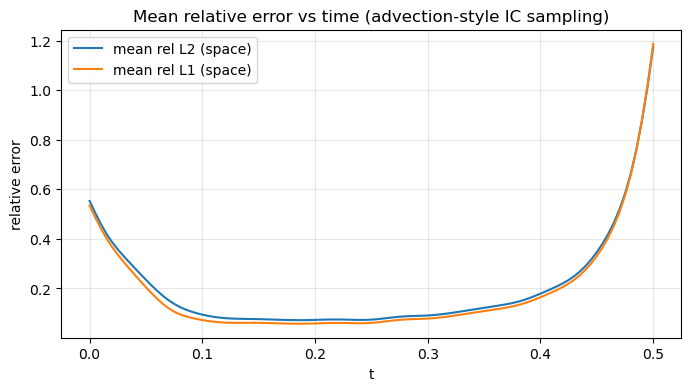

In [8]:
plt.figure(figsize=(8,4))
plt.plot(t_grid, l2_time.mean(axis=0), label="mean rel L2 (space)")
plt.plot(t_grid, l1_time.mean(axis=0), label="mean rel L1 (space)")
plt.xlabel("t"); plt.ylabel("relative error")
plt.title("Mean relative error vs time (advection-style IC sampling)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

<h2>Old 2D BURGERs codes</h2>

In [4]:
from train_utils.datasets import Burgers2DLoader
from torch.utils.data import DataLoader

DATA_PATH = config["data"]["datapath"]
dcfg = config["data"]

loader = Burgers2DLoader(
    datapath=DATA_PATH,
    nx=dcfg["nx"], ny=dcfg.get("ny", dcfg["nx"]),
    nt=dcfg["nt"],
    sub=dcfg["sub"], sub_t=dcfg["sub_t"],
    N=dcfg["total_num"],
    t_interval=dcfg["time_interval"],
)

# Example: evaluate last 100 cases
N_test = 100
testset = loader.make_dataset(n_sample=N_test, train=False)
test_loader = DataLoader(testset, batch_size=1, shuffle=False)

xb, yb = next(iter(test_loader))
print("x:", xb.shape)  # (B,S,S,T,4)
print("y:", yb.shape)  # (B,S,S,T)


x: torch.Size([1, 64, 64, 101, 4])
y: torch.Size([1, 64, 64, 101])


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_snapshots(truth, pred, t_grid, t_list, title_prefix="Case"):
    """
    truth/pred: (S,S,T)
    t_grid: (T,)
    3 rows: Truth / Pred / |Pred-Truth|
    Dedicated right column for colorbars => no overlap, tighter spacing.
    """
    S, _, T = truth.shape

    def t_to_idx(t):
        return int(np.argmin(np.abs(t_grid - t)))

    idxs = [t_to_idx(t) for t in t_list]
    ncol = len(idxs)

    # Shared color scale for Truth+Pred
    vmin = min(truth[:, :, idxs].min(), pred[:, :, idxs].min())
    vmax = max(truth[:, :, idxs].max(), pred[:, :, idxs].max())

    # Shared color scale for |diff|
    err_stack = np.abs(pred[:, :, idxs] - truth[:, :, idxs])
    emin, emax = float(err_stack.min()), float(err_stack.max())

    # --- Layout: last column reserved for colorbars ---
    fig = plt.figure(figsize=(3.05*ncol + 1.2, 8.2))
    gs = gridspec.GridSpec(
        3, ncol + 1,
        width_ratios=[1]*ncol + [0.05],
        wspace=0.03, hspace=0.12
    )

    axes = np.empty((3, ncol), dtype=object)
    for i in range(3):
        for j in range(ncol):
            axes[i, j] = fig.add_subplot(gs[i, j])

    cax_main = fig.add_subplot(gs[0:2, -1])  # spans rows 0-1
    cax_err  = fig.add_subplot(gs[2, -1])    # row 2 only

    im_main = None
    im_err  = None

    for j, k in enumerate(idxs):
        im0 = axes[0, j].imshow(
            truth[:, :, k].T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=vmin, vmax=vmax
        )
        axes[0, j].set_title(f"Truth t={t_grid[k]:.3f}", fontsize=11)
        axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

        im1 = axes[1, j].imshow(
            pred[:, :, k].T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=vmin, vmax=vmax
        )
        axes[1, j].set_title(f"Pred t={t_grid[k]:.3f}", fontsize=11)
        axes[1, j].set_xticks([]); axes[1, j].set_yticks([])

        err = np.abs(pred[:, :, k] - truth[:, :, k])
        im2 = axes[2, j].imshow(
            err.T, origin="lower", extent=[0, 1, 0, 1],
            aspect="equal", vmin=emin, vmax=emax
        )
        axes[2, j].set_title(f"|Diff| t={t_grid[k]:.3f}", fontsize=11)
        axes[2, j].set_xticks([]); axes[2, j].set_yticks([])

        if im_main is None: im_main = im0
        if im_err  is None: im_err  = im2

    cb1 = fig.colorbar(im_main, cax=cax_main)
    cb1.set_label("u", rotation=90)

    cb2 = fig.colorbar(im_err, cax=cax_err)
    cb2.set_label("|pred - truth|", rotation=90)

    fig.suptitle(title_prefix, y=0.99, fontsize=13)
    fig.subplots_adjust(top=0.93)  # keep title from colliding
    plt.show()


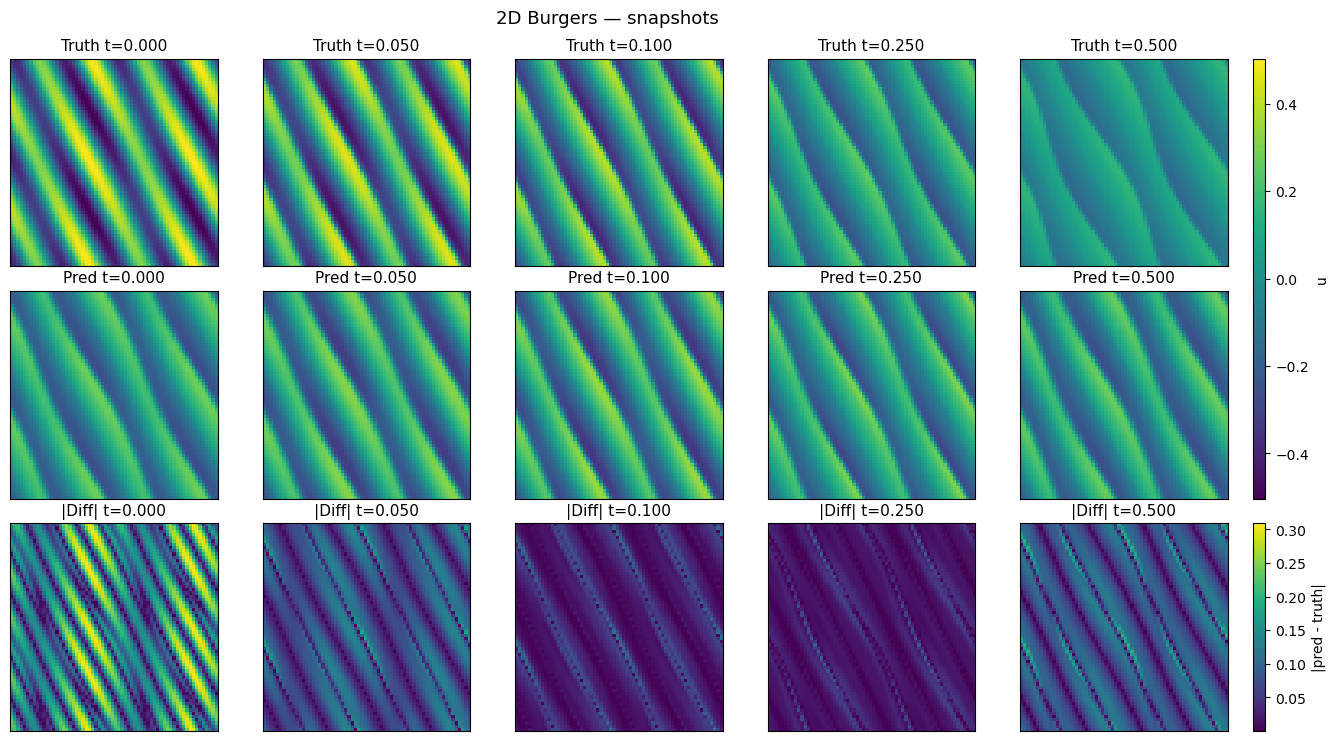

In [6]:
# pick one sample
x, y = next(iter(test_loader))
x = x.to(device)
y = y.to(device)

with torch.no_grad():
    out = model(x).reshape(y.shape)

truth = y[0].detach().cpu().numpy()     # (S,S,T)
pred  = out[0].detach().cpu().numpy()   # (S,S,T)

T = truth.shape[-1]
t_max = dcfg["time_interval"]
t_grid = np.linspace(0.0, t_max, T)

t_list = [0.0, 0.1*t_max, 0.2*t_max, 0.5*t_max, 1.0*t_max]
plot_snapshots(truth, pred, t_grid, t_list, title_prefix="2D Burgers — snapshots")


<h2>Test the model</h2>

Mean rel L2 (space-time): 0.3952758
Std  rel L2 (space-time): 0.11225286
Mean rel L1 (space-time): 0.31126088
Std  rel L1 (space-time): 0.08341995


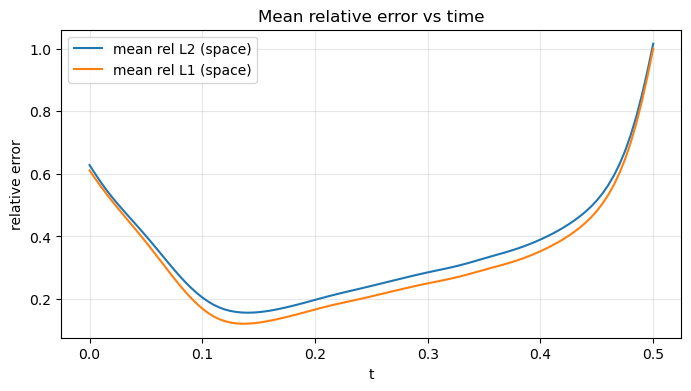

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def rel_l2(a, b, eps=1e-12):
    return np.linalg.norm(a-b) / (np.linalg.norm(b) + eps)

def rel_l1(a, b, eps=1e-12):
    return np.sum(np.abs(a-b)) / (np.sum(np.abs(b)) + eps)

l2_all, l1_all = [], []
l2_time, l1_time = [], []

with torch.no_grad():
    for (x, y) in test_loader:
        x = x.to(device); y = y.to(device)
        out = model(x).reshape(y.shape)

        truth = y[0].detach().cpu().numpy()   # (S,S,T)
        pred  = out[0].detach().cpu().numpy() # (S,S,T)

        # overall relative L2/L1 over space-time
        l2_all.append(rel_l2(pred.ravel(), truth.ravel()))
        l1_all.append(rel_l1(pred.ravel(), truth.ravel()))

        # per-time relative L2/L1 (space only)
        T = truth.shape[-1]
        l2_t = [rel_l2(pred[:, :, k].ravel(), truth[:, :, k].ravel()) for k in range(T)]
        l1_t = [rel_l1(pred[:, :, k].ravel(), truth[:, :, k].ravel()) for k in range(T)]
        l2_time.append(l2_t)
        l1_time.append(l1_t)

l2_all = np.array(l2_all)
l1_all = np.array(l1_all)
l2_time = np.array(l2_time)  # (N_test,T)
l1_time = np.array(l1_time)

print("Mean rel L2 (space-time):", l2_all.mean())
print("Std  rel L2 (space-time):", l2_all.std())
print("Mean rel L1 (space-time):", l1_all.mean())
print("Std  rel L1 (space-time):", l1_all.std())

t_axis = np.linspace(0.0, dcfg["time_interval"], l2_time.shape[1])

plt.figure(figsize=(8,4))
plt.plot(t_axis, l2_time.mean(axis=0), label="mean rel L2 (space)")
plt.plot(t_axis, l1_time.mean(axis=0), label="mean rel L1 (space)")
plt.xlabel("t")
plt.ylabel("relative error")
plt.title("Mean relative error vs time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<h2>Old Advection Eqn</h2>

In [5]:
def format_advection_data(data_dict):
    """
    Reshapes the Burgers dataset into a coordinate-based format.
    
    Args:
        data_dict (dict): Dictionary with keys 'x' (N, Nx) and 'y' (N, Nt, Nx).
        
    Returns:
        np.array: A single array of shape (N_SAMPLES, Nt, Nx, 3).
                  Channel 0: u0(x) repeated over time
                  Channel 1: x coordinates
                  Channel 2: t coordinates
    """
    # 1. Extract dimensions
    # data_dict['x'] is the initial condition u0, shape (N, Nx)
    # data_dict['y'] is the solution u, shape (N, Nt, Nx)
    u0 = data_dict['x'] 
    N_samples, Nx = u0.shape
    Nt = data_dict['y'].shape[1]
    
    print(f"Dimensions detected: N={N_samples}, Nt={Nt}, Nx={Nx}")

    # 2. Create Mesh Grids (Nt, Nx)
    # Recreate the grids used in the solver
    x_1d = np.linspace(0, 1, Nx, endpoint=False)
    t_1d = np.linspace(0, 1, Nt)
    
    # Create 2D grids. indexing='ij' ensures output is (Nt, Nx)
    # T_grid varies along axis 0, X_grid varies along axis 1
    T_grid, X_grid = np.meshgrid(t_1d, x_1d, indexing='ij')
    
    # 3. Broadcast/Repeat Arrays to shape (N, Nt, Nx)
    
    # Channel 0: u0 (Initial Condition)
    # Input: (N, Nx) -> Expand to (N, 1, Nx) -> Tile to (N, Nt, Nx)
    u0_expanded = np.tile(u0[:, None, :], (1, Nt, 1))
    
    # Channel 1: X Grid
    # Input: (Nt, Nx) -> Expand to (1, Nt, Nx) -> Broadcast to (N, Nt, Nx)
    X_expanded = np.tile(X_grid[None, :, :], (N_samples, 1, 1))
    
    # Channel 2: T Grid
    # Input: (Nt, Nx) -> Expand to (1, Nt, Nx) -> Broadcast to (N, Nt, Nx)
    T_expanded = np.tile(T_grid[None, :, :], (N_samples, 1, 1))
    
    # 4. Stack along the last axis
    # Result shape: (N, Nt, Nx, 3, 1)
    formatted_data = np.stack([u0_expanded, X_expanded, T_expanded], axis=-1)
    
    return formatted_data

In [6]:
# Create test data
data_dict = create_advection_dataset(N_SAMPLES=1000, Nx=100, Nt=101, X_MUL=4, T_MUL=4)

formatted_inputs = format_advection_data(data_dict)
formatted_inputs.shape

Generating 1000 samples of time-dependent traffic equation ...
Processing sample 50/1000...
Processing sample 100/1000...
Processing sample 150/1000...
Processing sample 200/1000...
Processing sample 250/1000...
Processing sample 300/1000...
Processing sample 350/1000...
Processing sample 400/1000...
Processing sample 450/1000...
Processing sample 500/1000...
Processing sample 550/1000...
Processing sample 600/1000...
Processing sample 650/1000...
Processing sample 700/1000...
Processing sample 750/1000...
Processing sample 800/1000...
Processing sample 850/1000...
Processing sample 900/1000...
Processing sample 950/1000...
Processing sample 1000/1000...

Generation complete.
x shape: (1000, 100)
y shape: (1000, 101, 100)
Dimensions detected: N=1000, Nt=101, Nx=100


(1000, 101, 100, 3)

In [27]:
import scipy

# We map 'x' -> 'input' and 'y' -> 'output'
mat_data = {
    'input': data_dict['x'],
    'output': data_dict['y']
}

# 3. Save to .mat file
# do_compression=True helps if the arrays are large
scipy.io.savemat('/home/tp526/neuraloperator/data/test_data/advection_truth_x100_t101_1000.mat', mat_data, do_compression=True)

print("Saved to /home/tp526/neuraloperator/data/test_data/advection_truth_x100_t101_1000.mat")

Saved to /home/tp526/neuraloperator/data/test_data/advection_truth_x100_t101_1000.mat


Input shape:  torch.Size([1, 101, 100, 3])
Output shape:  torch.Size([1, 101, 100])


==Relative L2 error mean:  0.043267==

Ground Truth


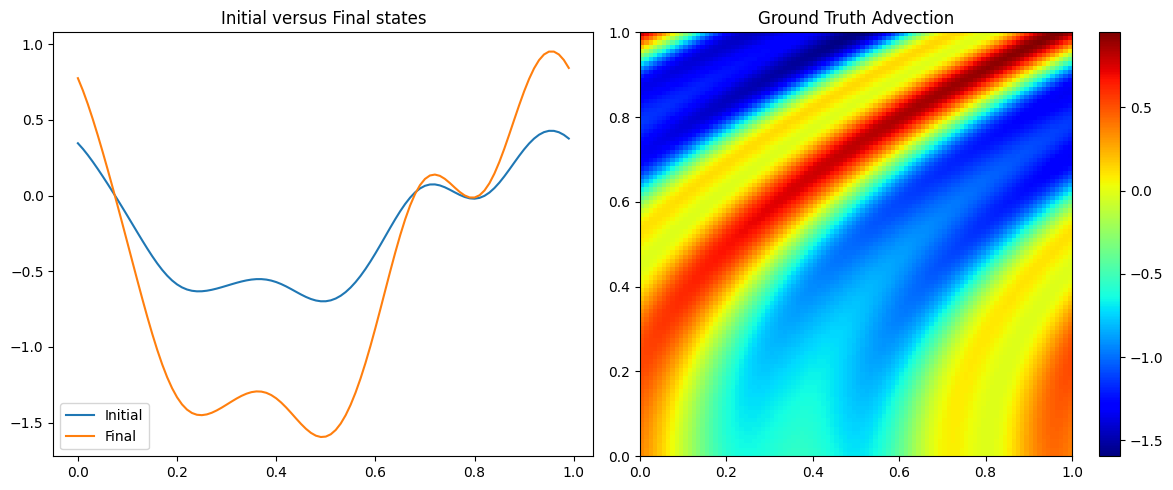

Prediction


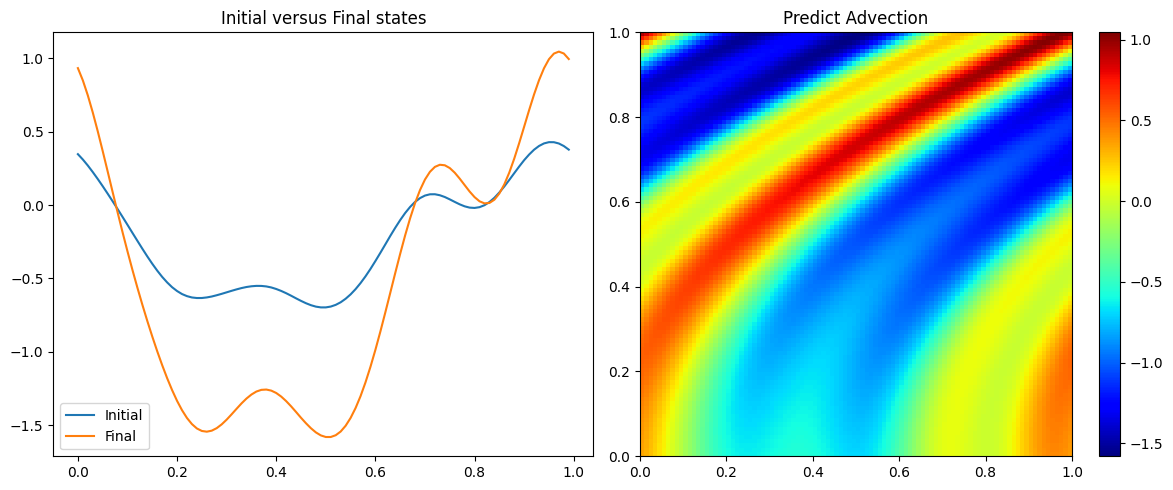

In [25]:
k = np.random.randint(1000)

x, y = torch.tensor(formatted_inputs[k:k+1], dtype=torch.float32).to(device), torch.tensor(data_dict["y"][k:k+1], dtype=torch.float32).to(device)

print("Input shape: ", x.shape)
print("Output shape: ", y.shape)
print("\n")

out = model(x).reshape(y.shape)

data_loss = torch.norm(out - y) / torch.norm(y)

print(f'==Relative L2 error mean: {data_loss.item() : .6f}==\n')

# Plot
print("Ground Truth")
truth = y[0].detach().cpu().numpy()
x_grid = np.linspace(0, 1, truth.shape[1], endpoint=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_grid, truth[0], label="Initial")
plt.plot(x_grid, truth[-1], label="Final")
plt.title("Initial versus Final states")
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(truth, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="jet")
plt.title("Ground Truth Advection")
plt.colorbar()

plt.tight_layout()
plt.show()

print("Prediction")
pred = out[0].detach().cpu().numpy()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_grid, pred[0], label="Initial")
plt.plot(x_grid, pred[-1], label="Final")
plt.title("Initial versus Final states")
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(pred, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="jet")
plt.title("Predict Advection")
plt.colorbar()

plt.tight_layout()
plt.show()



In [31]:
dataset = BurgersLoader("/home/tp526/neuraloperator/data/burgers_pino.mat",
                            nx=128, nt=100,
                            sub=1, sub_t=1, new=True)
train_loader = dataset.make_loader(n_sample=10,
                                    batch_size=1,
                                    start=0)

/home/tp526/.conda/envs/dde/lib/python3.11/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [9]:
import scipy

# We map 'x' -> 'input' and 'y' -> 'output'
mat_data = {
    'input': data_dict['x'],
    'output': data_dict['y'],
    'visc': data_dict['visc']
}

# 3. Save to .mat file
# do_compression=True helps if the arrays are large
scipy.io.savemat('/home/tp526/neuraloperator/data/traffic_pino.mat', mat_data, do_compression=True)

print("Saved to /home/tp526/neuraloperator/data/traffic_pino.mat")

Saved to /home/tp526/neuraloperator/data/traffic_pino.mat


In [16]:
print("-" * 100)
print("\nNumber of trainable parameters: ", sum(p.numel() for p in model.parameters()))
print("\n" + "-" * 100)

----------------------------------------------------------------------------------------------------

Number of trainable parameters:  933281

----------------------------------------------------------------------------------------------------


<h2>Test</h2>

In [26]:
#model.eval()

N_CASE = formatted_inputs.shape[0]

l2_errors = np.zeros(N_CASE)
l1_errors = np.zeros(N_CASE)

with torch.no_grad():
    for k in range(N_CASE):
        x = torch.tensor(formatted_inputs[k:k+1], dtype=torch.float32).to(device)
        y = torch.tensor(data_dict["y"][k:k+1], dtype=torch.float32).to(device)

        out = model(x).reshape(y.shape)

        # Relative L2
        l2 = torch.norm(out - y, p=2) / torch.norm(y, p=2)
        l2_errors[k] = l2.item()

        # Relative L1
        l1 = torch.norm(out - y, p=1) / torch.norm(y, p=1)
        l1_errors[k] = l1.item()

        if (k+1) % 20 == 0:
            print(f'Sample {k+1}/{N_CASE}: ')
            print(f'    Mean L2-relative-error: {np.mean(l2_errors[:(k+1)]):.6e}')
            print(f'    Mean L1-relative-error: {np.mean(l1_errors[:(k+1)]):.6e}')
            print("-" * 50 + "\n")

print(f"Mean L2-relative-error over 1000 tests: {np.mean(l2_errors):.6e}")
print(f"Mean L1-relative-error over 1000 tests: {np.mean(l1_errors):.6e}")
print(f"L2 std: {np.std(l2_errors):.6e}")
print(f"L1 std: {np.std(l1_errors):.6e}")


Sample 20/1000: 
    Mean L2-relative-error: 3.101646e-02
    Mean L1-relative-error: 2.261911e-02
--------------------------------------------------

Sample 40/1000: 
    Mean L2-relative-error: 3.191612e-02
    Mean L1-relative-error: 2.270735e-02
--------------------------------------------------

Sample 60/1000: 
    Mean L2-relative-error: 3.291990e-02
    Mean L1-relative-error: 2.329526e-02
--------------------------------------------------

Sample 80/1000: 
    Mean L2-relative-error: 3.277287e-02
    Mean L1-relative-error: 2.328359e-02
--------------------------------------------------

Sample 100/1000: 
    Mean L2-relative-error: 3.321941e-02
    Mean L1-relative-error: 2.358730e-02
--------------------------------------------------

Sample 120/1000: 
    Mean L2-relative-error: 3.389286e-02
    Mean L1-relative-error: 2.402999e-02
--------------------------------------------------

Sample 140/1000: 
    Mean L2-relative-error: 3.455177e-02
    Mean L1-relative-error: 2.441